In [3]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_svmlight_file
from scipy.stats import levy_stable


In [4]:
# 1. SETUP & DATA LOADING
# Using A9a dataset (Binary Classification)
# You can download 'a9a' from LIBSVM website or use a local path
def get_data():
    # For a quick start, let's generate a synthetic sharp dataset if a9a isn't local
    # But for your project, replace this with: load_svmlight_file('a9a.txt')
    X = torch.randn(2000, 123) 
    y = torch.randint(0, 2, (2000,)).float()
    return X, y

X, y = get_data()


In [7]:
# 2. DEFINING THE MODEL & NON-CONVEX LOSS
class NonConvexLogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(NonConvexLogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1, bias=False)
        
    def forward(self, x):
        return self.linear(x).squeeze()

def non_convex_regularizer(model, lam=0.1, alpha=1.0):
    reg = 0
    for param in model.parameters():
        # Geman-McClure: sum( (lam * w^2) / (1 + alpha * w^2) )
        reg += torch.sum((lam * param**2) / (1 + alpha * param**2))
    return reg



In [8]:
# 3. NOISE GENERATION (Lévy / Heavy-Tailed)
def add_heavy_tailed_noise(grad, alpha_levy=1.5, scale=0.01):
    """
    alpha_levy: 2.0 is Gaussian, 1.0 is Cauchy (Heavier).
    The paper suggests alpha < 2 captures the 'spikes'.
    """
    noise = levy_stable.rvs(alpha_levy, 0, scale=scale, size=grad.shape)
    return grad + torch.from_numpy(noise).float()



In [9]:
# 4. TRAINING LOOP
def run_experiment(opt_type='sgd', alpha_levy=1.5, lr=0.01, epochs=100):
    model = NonConvexLogisticRegression(123)
    criterion = nn.BCEWithLogitsLoss()
    losses = []
    
    for epoch in range(epochs):
        # Full batch gradient for stability control, then add synthetic noise
        outputs = model(X)
        loss_val = criterion(outputs, y) + non_convex_regularizer(model)
        
        model.zero_grad()
        loss_val.backward()
        
        with torch.no_grad():
            for param in model.parameters():
                # Inject Heavy-Tailed Noise into the gradient
                noisy_grad = add_heavy_tailed_noise(param.grad, alpha_levy)
                
                if opt_type == 'sgd':
                    param -= lr * noisy_grad
                elif opt_type == 'signsgd':
                    # DSignSGD Step: sign(grad + noise)
                    param -= lr * torch.sign(noisy_grad)
        
        losses.append(loss_val.item())
    return losses



In [ ]:
# 5. RUNNING THE COMPARISON

# alpha = 1.3, lr = 0.01
print("Running Experiments...")
history_sgd = run_experiment(opt_type='sgd', alpha_levy=1.3, lr=0.01)
history_signsgd = run_experiment(opt_type='signsgd', alpha_levy=1.3, lr=0.01)


Running Experiments...


In [ ]:
# alpha = 2.0, lr = 0.01

print("Running Experiments...")
history_sgd = run_experiment(opt_type='sgd', alpha_levy=2, lr=0.01)
history_signsgd = run_experiment(opt_type='signsgd', alpha_levy=2, lr=0.01)

Running Experiments...


In [10]:
# alpha = 2.0, lr = 0.0001

print("Running Experiments...")
history_sgd = run_experiment(opt_type='sgd', alpha_levy=2, lr=0.0001)
history_signsgd = run_experiment(opt_type='signsgd', alpha_levy=2, lr=0.0001)

Running Experiments...


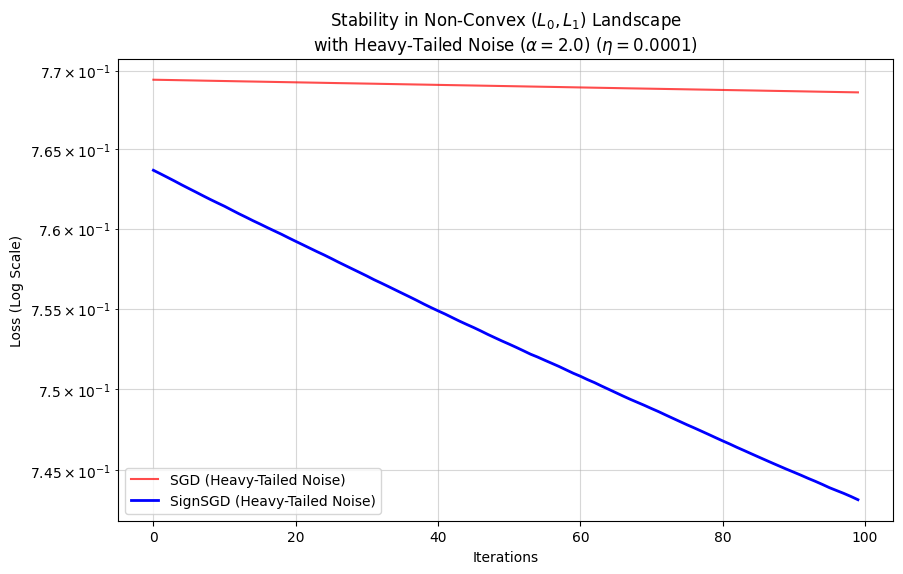

In [11]:
# 6. PLOTTING RESULTS
plt.figure(figsize=(10, 6))
plt.plot(history_sgd, label='SGD (Heavy-Tailed Noise)', color='red', alpha=0.7)
plt.plot(history_signsgd, label='SignSGD (Heavy-Tailed Noise)', color='blue', lw=2)
plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('Loss (Log Scale)')
plt.title('Stability in Non-Convex $(L_0, L_1)$ Landscape\nwith Heavy-Tailed Noise ($\\alpha=2.0$) ($\\eta=0.0001$)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

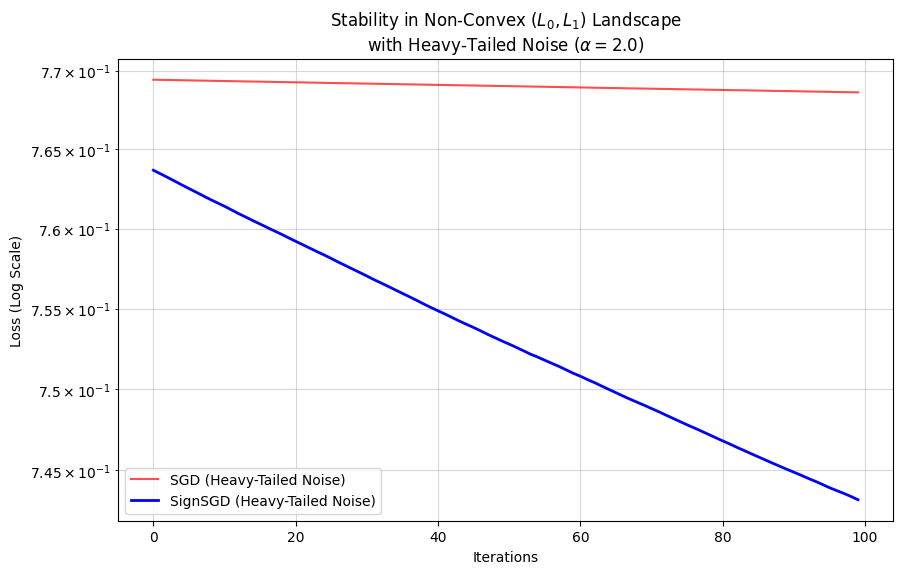

In [12]:
# 6. PLOTTING RESULTS
plt.figure(figsize=(10, 6))
plt.plot(history_sgd, label='SGD (Heavy-Tailed Noise)', color='red', alpha=0.7)
plt.plot(history_signsgd, label='SignSGD (Heavy-Tailed Noise)', color='blue', lw=2)
plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('Loss (Log Scale)')
plt.title('Stability in Non-Convex $(L_0, L_1)$ Landscape\nwith Heavy-Tailed Noise ($\\alpha=2.0$)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()